# SVM (Support Vector Machines)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_blobs

## 1. Importance of scaling

SVMs find the "widest possible gutter" (margin) between classes. Because this gutter is defined by the distance between points, features with larger numerical ranges can dominate the calculation and lead to poor models.

1. Observe the "Unscaled" data (where x1 is much larger than x0).
2. Apply `StandardScaler` to the data.
3. Fit a Linear SVM to both and compare how the decision boundary changes. Plot for visualization.

In [4]:
X_unscaled = np.array([[1, 50], [5, 20], [3, 80], [5, 60]])
y_unscaled = np.array([0, 0, 1, 1])

## 2. Choosing the Right Kernel

Different datasets require different "Kernel Tricks" to map data into higher dimensions where they become separable.
- **Linear**: Best for high-dimensional linear data.
- **Polynomial**: Simulates features like $x^2$.
- **RBF** (Gaussian): Maps to infinite-dimensional space (default in `sklearn`).

1. Try fitting three different kernels: 'linear', 'poly' with an even degree (2/4), 'poly' with an odd degree (3/5) and 'rbf' on the dataset created by `make_moons`.
2. Which one captures the shape best without overfitting? Which one seems to be underfitting? Plot the decision boundaries for each kernel to visualize the differences.

In [6]:
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

In [1]:
## feel free to either use this method or make your own to plot the decision boundaries for each kernel

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_new).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, alpha=0.3, cmap='brg')

## 3. Hyperparameter Tuning: C and Gamma

Tuning SVMs is a balance:
- C: Controls margin violations. Large C = less tolerance for errors (overfitting).
- Gamma (γ): Controls the "curve" of the boundary. Higher gamma = tighter fit.

1. Run the code below with the 'rbf' kernel.
2. Change the values of C and Gamma to see how the "regions" separate. Play around with both high and low values for C and Gamma, combined with each other.
3. Find a combination that looks like "Underfitting" (too smooth), "Overfitting" (too wiggly), and "Just Right" (good separation without too much complexity). Plot the decision boundaries for each case to visualize the differences.

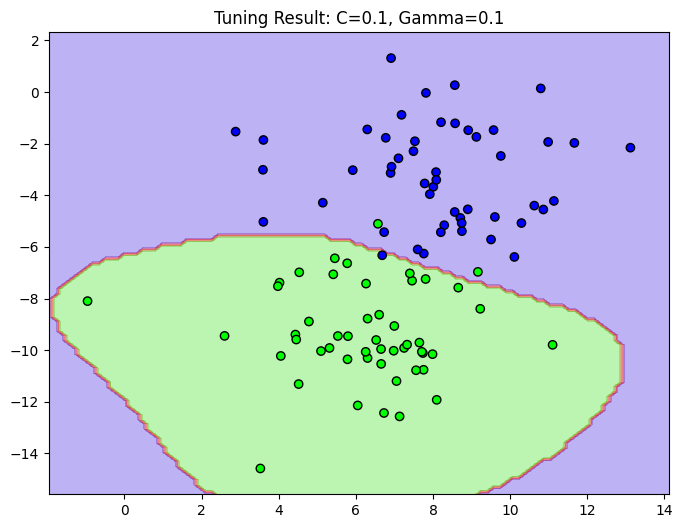

In [16]:
C_val = 0.1
gamma_val = 0.1

X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=2.0)

model = SVC(kernel='rbf', C=C_val, gamma=gamma_val).fit(X, y)

plt.figure(figsize=(8, 6))
plot_predictions(model, [X[:,0].min()-1, X[:,0].max()+1, X[:,1].min()-1, X[:,1].max()+1])
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg', edgecolors='k')
plt.title(f"Tuning Result: C={C_val}, Gamma={gamma_val}")
plt.show()